# Machine Learning Fundamentals

In this notebook, I will learn and practice: 

- Supervised and unsupervised learning
- Regression and classification
- Features and targets
- Training and test datasets
- Model training and prediction
- MSE, RMSE and MAE evaluation metrics

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [4]:
data = {
    "study_hours": [
        1.0,
        1.5,
        2.0,
        2.5,
        3.0,
        3.5,
        4.0,
        4.5,
        5.0,
        5.5,
        6.0,
        6.5,
        7.0,
        7.5,
        8.0
    ],
    "exam_score": [
        32,
        37,
        41,
        45,
        50,
        55,
        58,
        63,
        66,
        70,
        74,
        79,
        82,
        87,
        91
    ],
}

df = pd.DataFrame(data)
df

,study_hours,exam_score
0,1.0,32
1,1.5,37
2,2.0,41
3,2.5,45
4,3.0,50
5,3.5,55
6,4.0,58
7,4.5,63
8,5.0,66
9,5.5,70


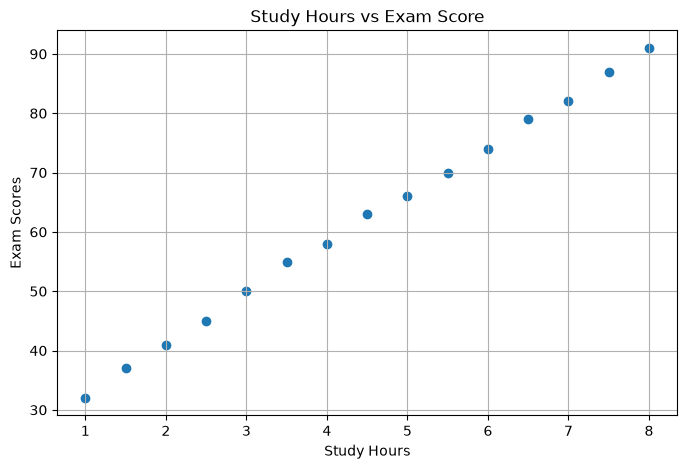

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["study_hours"],
    df["exam_score"]
)

plt.xlabel("Study Hours")
plt.ylabel("Exam Scores")

plt.title("Study Hours vs Exam Score")
plt.grid(True)

plt.show()

## Feature vs Target

In [9]:
X = df[["study_hours"]]
y = df["exam_score"]

print("X Shape: ", X.shape)
print("Y Shape: ", y.shape)

X Shape:  (15, 1)
Y Shape:  (15,)


## Train vs Test

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state=42
)

In [12]:
print("Training Examples: ", len(X_train))
print("Test Examples: ", len(X_test))

print("\nX_train: ")
display(X_train)

print("\nX_test: ")
display(X_test)

Training Examples:  12
Test Examples:  3

X_train: 


,study_hours
13,7.5
5,3.5
8,5.0
2,2.0
1,1.5
14,8.0
4,3.0
7,4.5
10,6.0
12,7.0



X_test: 


,study_hours
9,5.5
11,6.5
0,1.0


# Model Training

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[8.25]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['study_hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,24.97
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [15]:
print("Coefficient: ", model.coef_[0])
print("Intercept: ", model.intercept_)

Coefficient:  8.245752666930066
Intercept:  24.967206637692613


In [22]:
study_hours = 6.25


manual_prediction = (
    model.coef_[0] * study_hours + model.intercept_)
print(f"Manual Prediction: {manual_prediction:.2f}")

Manual Prediction: 76.50


In [27]:
new_data = pd.DataFrame({
    "study_hours": [9]
})

model_prediction = model.predict(new_data)

print(f"Model Prediction: {model_prediction[0]:.2f}")

Model Prediction: 99.18


In [31]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "study_hours": X_test["study_hours"],
    "actual_score": y_test,
    "predicted_score": y_pred,
})

results

,study_hours,actual_score,predicted_score
9,5.5,70,70.318846
11,6.5,79,78.564599
0,1.0,32,33.212959


In [32]:
mse = mean_squared_error(y_test, y_pred)
rmse= np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE  :  {mse:.4f}")
print(f"RMSE :  {rmse:.4f}")
print(f"MAE  :  {mae:.4f}")

MSE  :  0.5875
RMSE :  0.7665
MAE  :  0.6557


## Regression Line

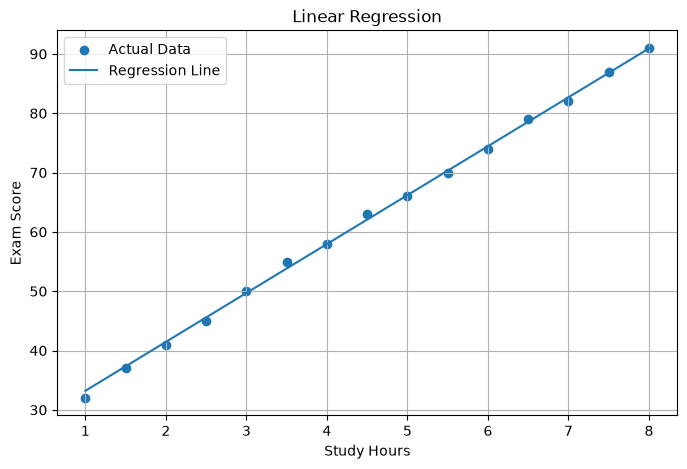

In [33]:
X_sorted = X.sort_values(by="study_hours")
y_line = model.predict(X_sorted)

plt.figure(figsize = (8, 5))

plt.scatter(
    df["study_hours"],
    df["exam_score"],
    label="Actual Data")

plt.plot(
    X_sorted["study_hours"],
    y_line,
    label="Regression Line")

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)

plt.show()

## Using model with new data

In [36]:
new_data = pd.DataFrame({
    "study_hours":[6.25]})

predicted_score = model.predict(new_data)

print(f"Predicted Score for 6.25 study hours: {predicted_score[0]:.2f}")

Predicted Score for 6.25 study hours: 76.50


## What I Learned

- This is a supervised learning problem because the dataset contains both input values and known output values.
- This is a regression problem because the target is numerical
- The feature is the number of study hours.
- The target is the exam score
- The model learns using the training dataset
- The test dataset is used to measure performance on unseen examples
- MSE, RMSE and MAE measure the difference between actuaş and predicted values